### A notebook to create croparray objects from videos and tracking files. Can run on lists of files in batch.

In [1]:
import croparray as ca
from pathlib import Path

In [10]:
# ============================
# USER-DEFINED PARAMETERS
# ============================

# Input files
DATA_DIR = Path(r"\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260325_ZAK_KO_ST_KDM5B\wDox\HT")

CSV_FILES = sorted(DATA_DIR.glob("PB_MAX*_allspots.csv"))
VID_FILES = sorted(DATA_DIR.glob("PB_MAX*.tif"))
assert len(VID_FILES) == len(CSV_FILES), f"Mismatch: {len(VID_FILES)} videos vs {len(CSV_FILES)} csvs"

# Cropping parameters
XY_PAD = 10                         # Typically 5, but bigger if spots are > diffraction limited
Z_PAD = 1                           # Only used if tracking was also done in Z

# Physical metadata (should match TrackMate if TrackMate units not pixels)
DX = 0.074*2  ## pulled from images files from marianas
DY = 0.074*2 
DZ = .35      ## this is ignored if tracking was only done in 2D
DT = 1
UNITS = ["microns", "min"]
NOTES = 'A crop array in KO Zak U2OS cells with tet-inducible HA-Zak. This is the +DOX condition, so should have HA-Zak expressed to rescue phenotype. Ch0 = 12xSunTag-KDM5B-MS2 labeled with mEGFP-tagged anti-SunTag scFv. ch1 = mSc3-tagged anti-HA scFv (to label HA-Zak if induced; not imaged). ch3 = MCP-Halo labeled with JF646 (not imaged). Used Sun+HA+MCP APP. Spots were tracked in 2D on Max-projections using TrackMate.'
DATE_STR = "2026-03-25"

# Spot table handling
TRACKER = "auto"  # "trackmate" or "trackpy"; "auto" automatically determines; None for croparray
KEEP_COLS = ["MEAN_INTENSITY_CH1","TOTAL_INTENSITY_CH1", "CONTRAST_CH1", "SNR_CH1"]  # Optional; Note: sister colums are kept too (_CH2, _CH3...)

# ====================================
# PARAMETERS THAT DON'T NEED TO CHANGE
# ====================================
# Output
OUT_SUBDIR = "CropArrays"          # created inside DATA_DIR
OUT_EXT = ".nc"                    # standard is .nc, but can change

# Axis handling
AXES_SOURCE_INDEX = 0              # which video to use for axis definition; safe 0 (always there)


In [11]:
CSV_FILES, VID_FILES

([WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260325_ZAK_KO_ST_KDM5B/wDox/HT/PB_MAX_02_allspots.csv'),
  WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260325_ZAK_KO_ST_KDM5B/wDox/HT/PB_MAX_03_allspots.csv'),
  WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260325_ZAK_KO_ST_KDM5B/wDox/HT/PB_MAX_05_allspots.csv'),
  WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260325_ZAK_KO_ST_KDM5B/wDox/HT/PB_MAX_06_allspots.csv'),
  WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260325_ZAK_KO_ST_KDM5B/wDox/HT/PB_MAX_07_allspots.csv'),
  WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260325_ZAK_KO_ST_KDM5B/wDox/HT/PB_MAX_08_allspots.csv')],
 [WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260325_ZAK_KO_ST_KDM5B/wDox/HT/PB_MAX_02.tif'),
  WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260325_ZAK_KO_ST_KDM5B/wDox/HT/PB_MAX_03.tif'),
 

In [12]:
# Build and save croparrays. This will not overwrite existing croparrays (may need to restart kernel if you delete .nc files and try to rerun)
written = ca.build.make_croparrays(VID_FILES, CSV_FILES, out_dir=DATA_DIR/OUT_SUBDIR, out_ext=OUT_EXT, tracker=TRACKER, xy_um_per_px=DX, z_um_per_plane=DZ, define_axes=True, keep_cols=KEEP_COLS, axes_source_index=AXES_SOURCE_INDEX, xy_pad=XY_PAD, z_pad=Z_PAD, dx=DX, dy=DY, dz=DZ, dt=DT, units=UNITS, date=DATE_STR, notes=NOTES, as_object=False, skip_existing=True, progress=True)

croparray:  17%|█▋        | 1/6 [00:00<00:02,  2.43file/s]

Original video dimensions: (1, 46, 1, 512, 512, 1)
Padded video dimensions: (1, 46, 1, 534, 534, 1)
Max # of spots per frame: 37


croparray:  33%|███▎      | 2/6 [00:00<00:01,  2.46file/s]

Original video dimensions: (1, 46, 1, 512, 512, 1)
Padded video dimensions: (1, 46, 1, 534, 534, 1)
Max # of spots per frame: 19
Original video dimensions: (1, 46, 1, 512, 512, 1)
Padded video dimensions: (1, 46, 1, 534, 534, 1)
Max # of spots per frame: 229


croparray:  67%|██████▋   | 4/6 [00:01<00:00,  2.08file/s]

Original video dimensions: (1, 46, 1, 512, 512, 1)
Padded video dimensions: (1, 46, 1, 534, 534, 1)
Max # of spots per frame: 31
Original video dimensions: (1, 46, 1, 512, 512, 1)
Padded video dimensions: (1, 46, 1, 534, 534, 1)
Max # of spots per frame: 99


croparray:  83%|████████▎ | 5/6 [00:02<00:00,  1.96file/s]

Original video dimensions: (1, 46, 1, 512, 512, 1)
Padded video dimensions: (1, 46, 1, 534, 534, 1)
Max # of spots per frame: 97


croparray: 100%|██████████| 6/6 [00:02<00:00,  2.00file/s]


Check croparrays

In [13]:
NC_DIR = DATA_DIR/OUT_SUBDIR
NC_FILES = sorted(NC_DIR.glob("*.nc"))
NC_FILES

[WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260325_ZAK_KO_ST_KDM5B/wDox/HT/CropArrays/PB_MAX_02.nc'),
 WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260325_ZAK_KO_ST_KDM5B/wDox/HT/CropArrays/PB_MAX_03.nc'),
 WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260325_ZAK_KO_ST_KDM5B/wDox/HT/CropArrays/PB_MAX_05.nc'),
 WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260325_ZAK_KO_ST_KDM5B/wDox/HT/CropArrays/PB_MAX_06.nc'),
 WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260325_ZAK_KO_ST_KDM5B/wDox/HT/CropArrays/PB_MAX_07.nc'),
 WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260325_ZAK_KO_ST_KDM5B/wDox/HT/CropArrays/PB_MAX_08.nc')]

In [14]:
# Check croparray 
# Need to open this way to get proper doc strings:
from croparray.trackarray.object import CropArray
my_ca: CropArray = ca.io.open_croparray(NC_FILES[0], as_object=True)

[CropArray] No sidecars found.


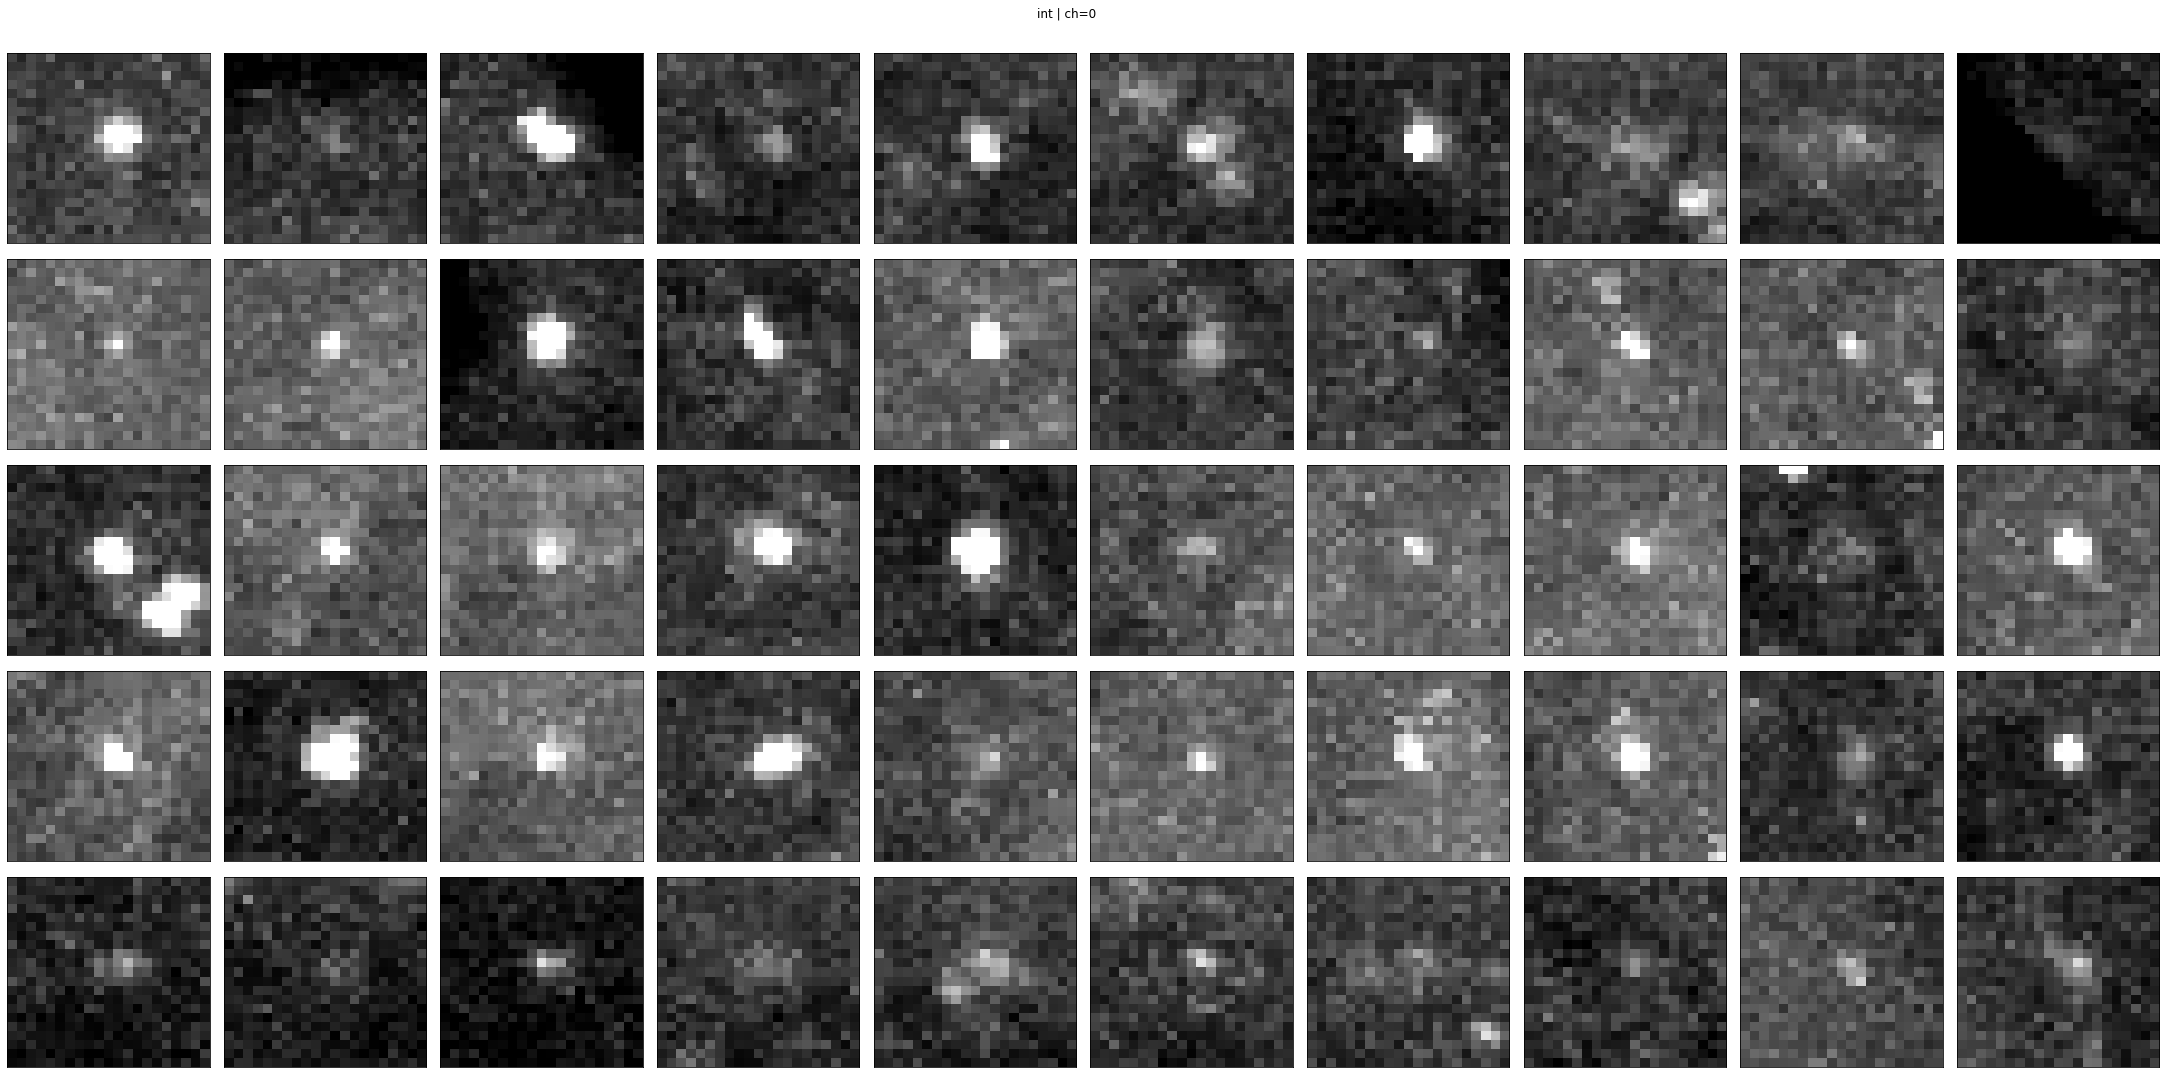

In [15]:
my_ca.isel(fov=0,z=0).plot.plot_croparray_crops(n=(0,10,1), layer='int',t=(0,5,1), col='n');

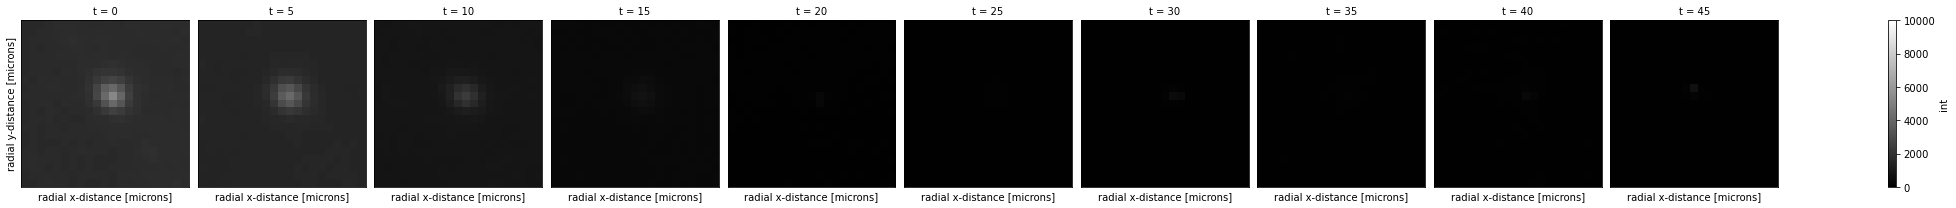

In [16]:
my_ca['int'].isel(ch=0,fov=0,z=0).mean(dim=['n']).rolling(t=5, center=True, min_periods=1).mean().isel(t=slice(None, None, 5)).plot.imshow(col="t", cmap='gray',robust=True, vmin=0,vmax=10000,xticks=[],yticks=[],)